<a href="https://colab.research.google.com/github/ruhmmachaudhary-rgb/movie-ratings-recommendation/blob/main/movie_recommendation_and_rating.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Import Libraries

In [14]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import ast
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set(style="whitegrid")

 2) Load ZIP Dataset

In [15]:

zip_file = '/content/archive (4).zip'
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall('data')


 3) Load CSVs

In [16]:

movies = pd.read_csv('data/tmdb_5000_movies.csv')
credits = pd.read_csv('data/tmdb_5000_credits.csv')
print("Movies Head:")
print(movies.head())
print("\nCredits Head:")
print(credits.head())

Movies Head:
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"i

 4) Merge Datasets

In [17]:

# Merge on movie ID
credits.rename(columns={'movie_id':'id'}, inplace=True)
df = movies.merge(credits, on='id')
print("\nMerged Data Head:")
df.head()



Merged Data Head:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,title_y,cast,crew
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


 5) Data Cleaning

In [18]:

# Keep relevant columns for EDA and ML
df_clean = df[['title_x','vote_average','vote_count','budget','popularity','runtime','genres','cast','crew']]
df_clean.rename(columns={'title_x':'title'}, inplace=True)

/tmp/ipykernel_16361/1183821922.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean.rename(columns={'title_x':'title'}, inplace=True)


In [19]:
# Convert genres JSON to list of names
df_clean['genres_list'] = df_clean['genres'].apply(lambda x: [i['name'] for i in ast.literal_eval(x)] if pd.notnull(x) else [])

/tmp/ipykernel_16361/623249223.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['genres_list'] = df_clean['genres'].apply(lambda x: [i['name'] for i in ast.literal_eval(x)] if pd.notnull(x) else [])


In [20]:
# Fill missing values in numeric columns
df_clean['budget'].fillna(df_clean['budget'].median(), inplace=True)
df_clean['popularity'].fillna(df_clean['popularity'].median(), inplace=True)
df_clean['runtime'].fillna(df_clean['runtime'].median(), inplace=True)

/tmp/ipykernel_16361/2291399974.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['budget'].fillna(df_clean['budget'].median(), inplace=True)
/tmp/ipykernel_16361/2291399974.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['budget'].fillna(df_clean['budget'].median(), inplace=True)
/tmp/ipykernel_16361/2291399974.py:3: F

In [21]:
# Create "popular" label: 1 if vote_average >= 7 else 0
df_clean['popular'] = df_clean['vote_average'].apply(lambda x: 1 if x >= 7 else 0)

print("\nCleaned Data Head:")
df_clean.head()

/tmp/ipykernel_16361/425617117.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['popular'] = df_clean['vote_average'].apply(lambda x: 1 if x >= 7 else 0)



Cleaned Data Head:


,title,vote_average,vote_count,budget,popularity,runtime,genres,cast,crew,genres_list,popular
0,Avatar,7.2,11800,237000000,150.437577,162.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...","[Action, Adventure, Fantasy, Science Fiction]",1
1,Pirates of the Caribbean: At World's End,6.9,4500,300000000,139.082615,169.0,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...","[Adventure, Fantasy, Action]",0
2,Spectre,6.3,4466,245000000,107.376788,148.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...","[Action, Adventure, Crime]",0
3,The Dark Knight Rises,7.6,9106,250000000,112.312950,165.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...","[Action, Crime, Drama, Thriller]",1
4,John Carter,6.1,2124,260000000,43.926995,132.0,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...","[Action, Adventure, Science Fiction]",0


 6) Exploratory Data Analysis (EDA)

/tmp/ipykernel_16361/3642157527.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[i[0] for i in top_genres], y=[i[1] for i in top_genres], palette="viridis")


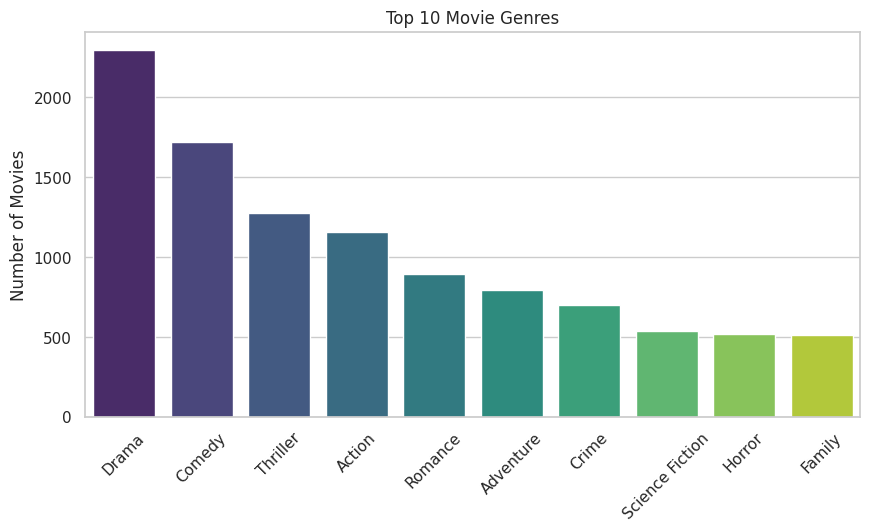

In [22]:

# Top 10 genres
from collections import Counter
all_genres = [genre for sublist in df_clean['genres_list'] for genre in sublist]
top_genres = Counter(all_genres).most_common(10)

plt.figure(figsize=(10,5))
sns.barplot(x=[i[0] for i in top_genres], y=[i[1] for i in top_genres], palette="viridis")
plt.title("Top 10 Movie Genres")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()

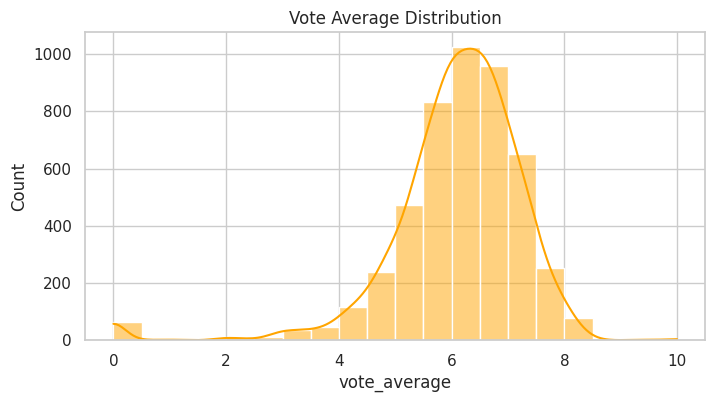

In [23]:
# Vote average distribution
plt.figure(figsize=(8,4))
sns.histplot(df_clean['vote_average'], bins=20, kde=True, color='orange')
plt.title("Vote Average Distribution")
plt.show()


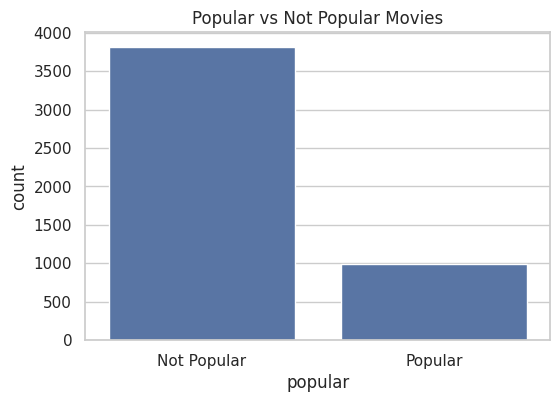

In [24]:
# Popular vs Not Popular movies
plt.figure(figsize=(6,4))
sns.countplot(x='popular', data=df_clean)
plt.title("Popular vs Not Popular Movies")
plt.xticks([0,1], ['Not Popular','Popular'])
plt.show()


7) Random Forest Classifier

In [25]:

# Features and target
X = df_clean[['budget','popularity','runtime']]
y = df_clean['popular']



In [26]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [27]:
# Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


In [28]:

# Evaluation
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nRandom Forest Accuracy: {acc}")
print("Random Forest Confusion Matrix:\n", cm)


Random Forest Accuracy: 0.8199791883454735
Random Forest Confusion Matrix:
 [[714  50]
 [123  74]]


 8) Key Observations

In [29]:

print("\nObservations:")
print("- Top genres include Drama, Comedy, Action, Thriller, Romance.")
print("- Most movies have vote_average < 7 (not very popular).")
print("- Random Forest predicts popular movies reasonably well using budget, popularity, and runtime.")


Observations:
- Top genres include Drama, Comedy, Action, Thriller, Romance.
- Most movies have vote_average < 7 (not very popular).
- Random Forest predicts popular movies reasonably well using budget, popularity, and runtime.
